In [1]:
!pip install pandas scikit-learn joblib

In [15]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import joblib

In [16]:
df = pd.read_csv('/content/gym_recommendation_dataset.csv')

df.head()

,Age,Gender,Weight,Height,Goal,Experience,Equipment,WorkoutTime,BMI,RecommendedExercise
0,18,Male,65,170,Muscle Gain,Beginner,Dumbbells,45,22.5,Strength Training
1,22,Female,55,160,Weight Loss,Beginner,NaN,30,21.5,Cardio
2,25,Male,75,175,Muscle Gain,Intermediate,Gym Machine,60,24.5,Hypertrophy Training
3,30,Female,68,165,Weight Loss,Intermediate,Treadmill,40,25.0,HIIT
4,28,Male,80,178,Strength,Advanced,Barbell,75,25.2,Powerlifting


In [17]:
print("Dataset Shape:")
print(df.shape)

print("\nDataset Columns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Dataset Shape:
(96, 10)

Dataset Columns:
Index(['Age', 'Gender', 'Weight', 'Height', 'Goal', 'Experience', 'Equipment',
       'WorkoutTime', 'BMI', 'RecommendedExercise'],
      dtype='object')

Data Types:
Age                      int64
Gender                  object
Weight                   int64
Height                   int64
Goal                    object
Experience              object
Equipment               object
WorkoutTime              int64
BMI                    float64
RecommendedExercise     object
dtype: object


In [18]:
print(df.isnull().sum())

Age                     0
Gender                  0
Weight                  0
Height                  0
Goal                    0
Experience              0
Equipment              20
WorkoutTime             0
BMI                     0
RecommendedExercise     0
dtype: int64


In [19]:
df.describe()

,Age,Weight,Height,WorkoutTime,BMI
count,96.000000,96.000000,96.000000,96.000000,96.000000
mean,28.979167,70.864583,170.395833,51.562500,24.158333
std,5.945328,12.935972,8.458542,19.645711,2.161124
min,18.000000,48.000000,156.000000,20.000000,19.700000
25%,24.000000,60.750000,163.750000,35.000000,22.575000
50%,28.500000,70.000000,170.000000,50.000000,24.450000
75%,34.000000,80.250000,178.000000,65.000000,25.600000
max,41.000000,96.000000,185.000000,90.000000,28.400000


In [20]:
categorical_cols = [
    'Gender',
    'Goal',
    'Experience',
    'Equipment',
    'RecommendedExercise'
]

for col in categorical_cols:
    print("\n", col)
    print(df[col].unique())


 Gender
['Male' 'Female']

 Goal
['Muscle Gain' 'Weight Loss' 'Strength' 'Fitness']

 Experience
['Beginner' 'Intermediate' 'Advanced']

 Equipment
['Dumbbells' nan 'Gym Machine' 'Treadmill' 'Barbell' 'Cycling' 'Yoga Mat']

 RecommendedExercise
['Strength Training' 'Cardio' 'Hypertrophy Training' 'HIIT' 'Powerlifting'
 'Yoga' 'Cycling' 'Pilates' 'Deadlift Training' 'Jump Rope'
 'Resistance Training' 'Endurance Training' 'Squat Training' 'Aerobics'
 'Bodybuilding' 'Walking']


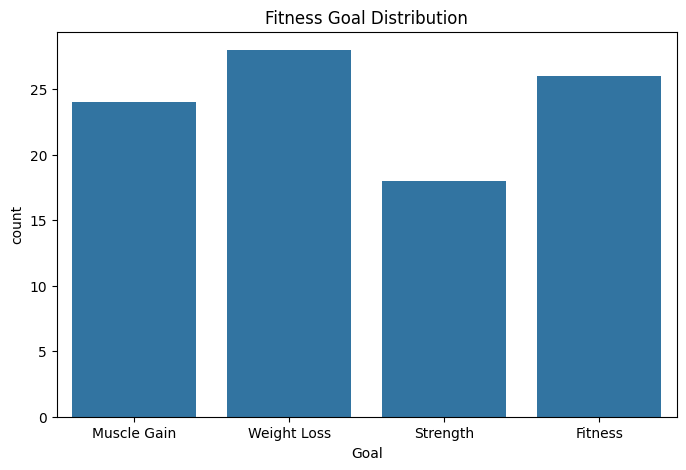

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(x='Goal', data=df)

plt.title("Fitness Goal Distribution")

plt.show()

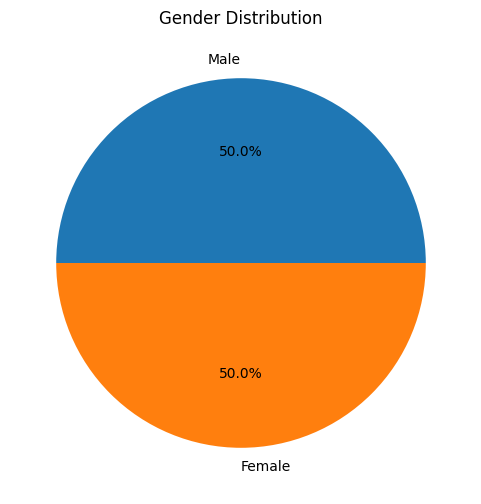

In [22]:
df['Gender'].value_counts().plot.pie(
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title("Gender Distribution")

plt.ylabel("")

plt.show()

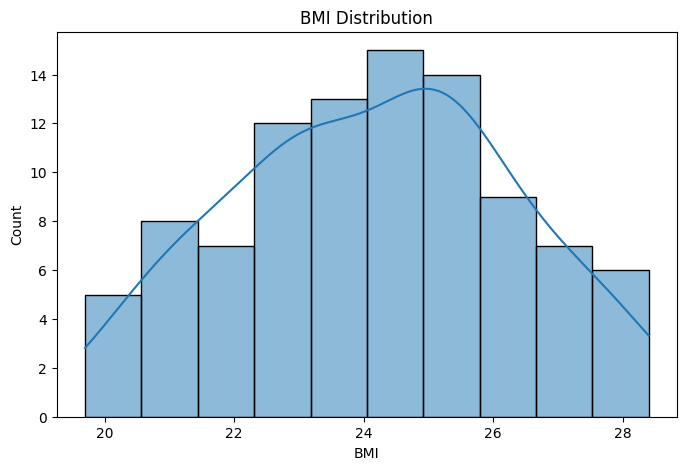

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(df['BMI'], bins=10, kde=True)

plt.title("BMI Distribution")

plt.show()

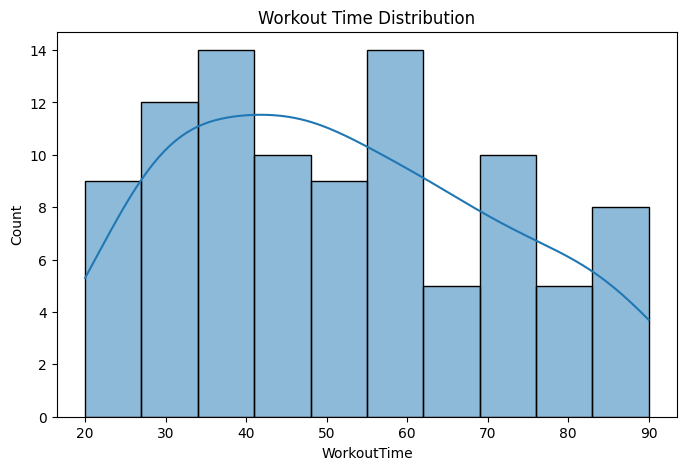

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(df['WorkoutTime'], bins=10, kde=True)

plt.title("Workout Time Distribution")

plt.show()

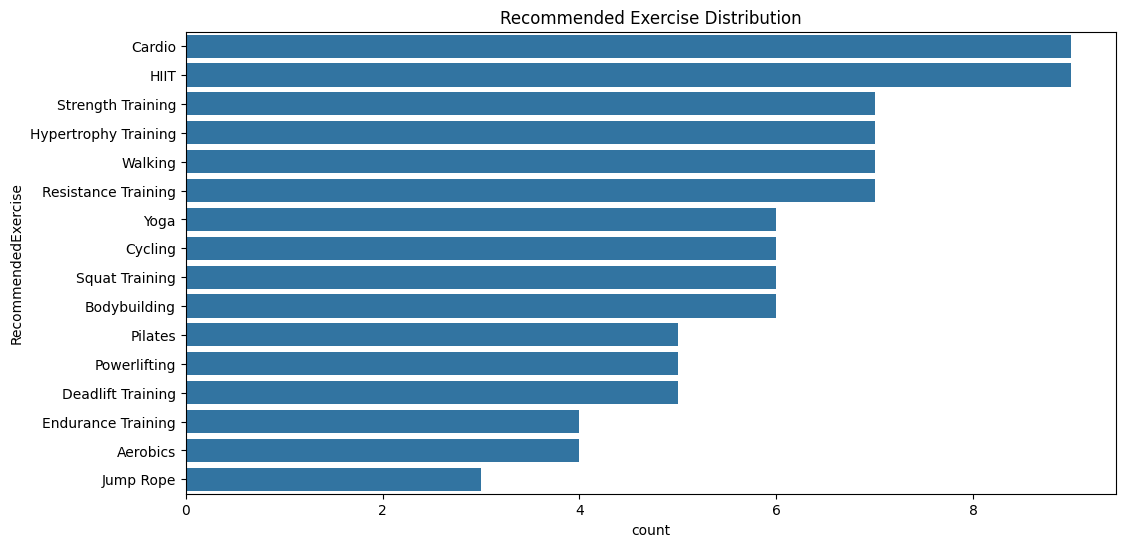

In [25]:
plt.figure(figsize=(12,6))

sns.countplot(
    y='RecommendedExercise',
    data=df,
    order=df['RecommendedExercise'].value_counts().index
)

plt.title("Recommended Exercise Distribution")

plt.show()

In [26]:
label_encoders = {}

for column in categorical_cols:

    le = LabelEncoder()

    df[column] = le.fit_transform(df[column])

    label_encoders[column] = le

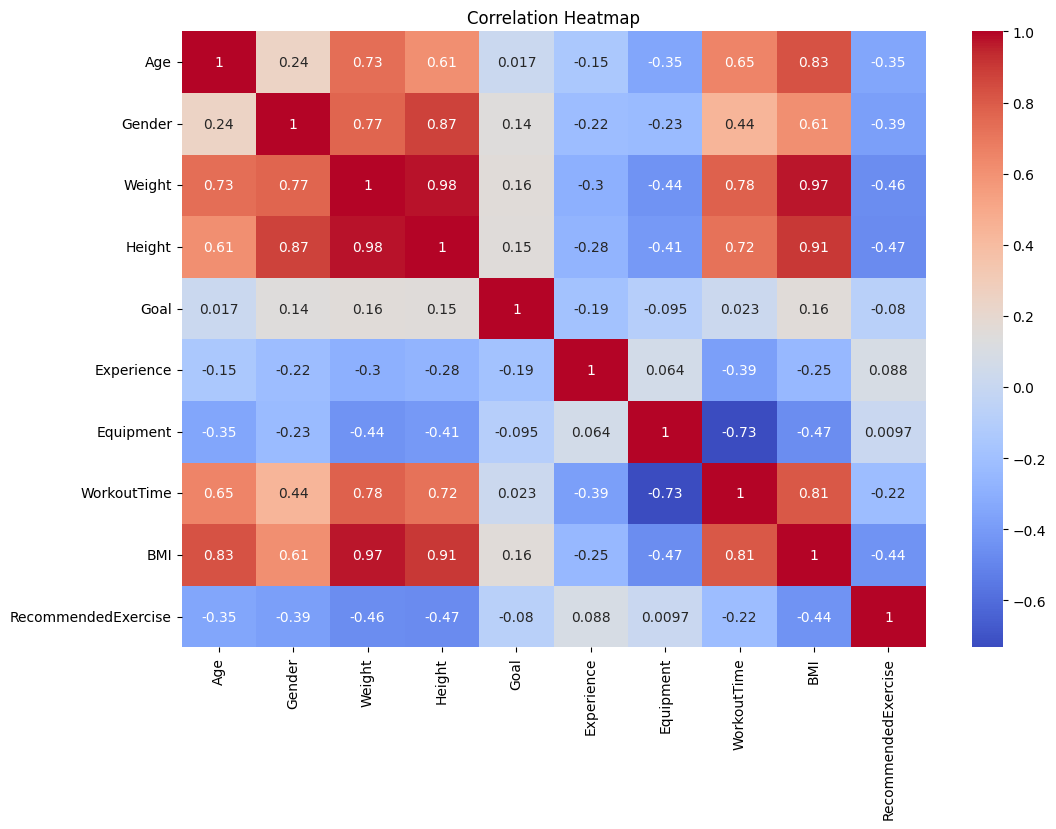

In [27]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [28]:
X = df.drop('RecommendedExercise', axis=1)

y = df['RecommendedExercise']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [30]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [31]:
y_pred = model.predict(X_test)

In [32]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.65


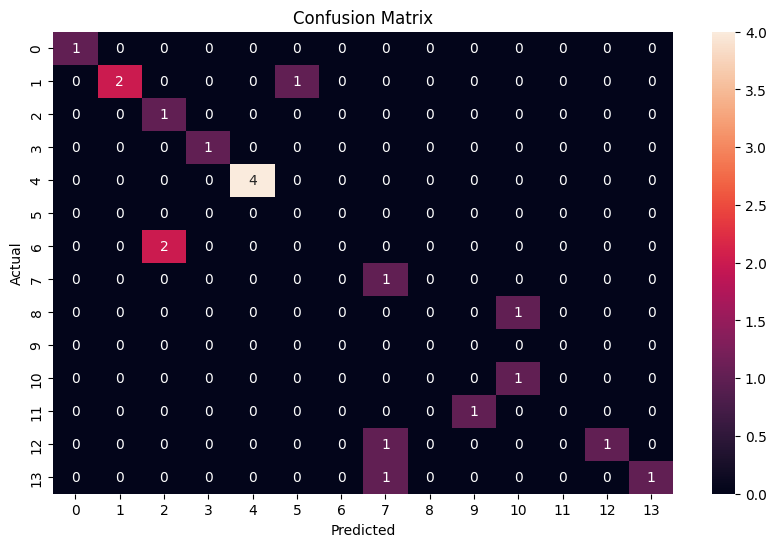

In [33]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [34]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      0.67      0.80         3
           2       0.33      1.00      0.50         1
           4       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         4
           7       0.00      0.00      0.00         0
           8       0.00      0.00      0.00         2
           9       0.33      1.00      0.50         1
          10       0.00      0.00      0.00         1
          11       0.00      0.00      0.00         0
          12       0.50      1.00      0.67         1
          13       0.00      0.00      0.00         1
          14       1.00      0.50      0.67         2
          15       1.00      0.50      0.67         2

    accuracy                           0.65        20
   macro avg       0.51      0.55      0.49        20
weighted avg       0.71      0.65      0.64        20



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [35]:
joblib.dump(model, 'gym_recommendation_model.pkl')

print("Model Saved Successfully")

Model Saved Successfully


In [36]:
loaded_model = joblib.load('gym_recommendation_model.pkl')

In [37]:
# Example User Input

age = 24
gender = 'Male'
weight = 70
height = 175
goal = 'Muscle Gain'
experience = 'Beginner'
equipment = 'Dumbbells'
workout_time = 45

# BMI Calculation

height_m = height / 100

bmi = weight / (height_m ** 2)

print("Calculated BMI:", bmi)

Calculated BMI: 22.857142857142858


In [38]:
gender_encoded = label_encoders['Gender'].transform([gender])[0]

goal_encoded = label_encoders['Goal'].transform([goal])[0]

experience_encoded = label_encoders['Experience'].transform([experience])[0]

equipment_encoded = label_encoders['Equipment'].transform([equipment])[0]

In [39]:
input_data = pd.DataFrame([{

    'Age': age,

    'Gender': gender_encoded,

    'Weight': weight,

    'Height': height,

    'Goal': goal_encoded,

    'Experience': experience_encoded,

    'Equipment': equipment_encoded,

    'WorkoutTime': workout_time,

    'BMI': bmi

}])

input_data

,Age,Gender,Weight,Height,Goal,Experience,Equipment,WorkoutTime,BMI
0,24,1,70,175,1,1,2,45,22.857143


In [40]:
prediction = loaded_model.predict(input_data)

predicted_exercise = label_encoders[
    'RecommendedExercise'
].inverse_transform(prediction)

print("Recommended Exercise:", predicted_exercise[0])

Recommended Exercise: Resistance Training
